In [20]:
import pandas as pd
import numpy as np
import scipy.io as sio
import torch
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from data_classes.decomposition import Extract_Features, PCA_features
import torchaudio

In [29]:
phase2_data = sio.loadmat('../data/phase2_data_20220215.mat')
samples  = pd.DataFrame(phase2_data["x"].T)
labels  = pd.DataFrame(phase2_data["y"].T, columns=["y"])

df = pd.concat([samples, labels], axis=1, join="inner").dropna()
display(df)

,0,1,2,3,4,5,6,7,8,9,...,4791,4792,4793,4794,4795,4796,4797,4798,4799,y
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000031,0.000000,0.000031,0.000000,-0.000061,0.000000,0.0
1,-0.000061,-0.000031,-0.000092,-0.000031,-0.000061,-0.000061,-0.000061,-0.000061,-0.000031,-0.000061,...,-0.000031,0.000031,-0.000061,0.000000,0.000031,0.000122,0.000031,0.000092,0.000092,0.0
2,0.000000,-0.000122,0.000000,-0.000061,-0.000031,-0.000031,0.000000,-0.000031,0.000031,-0.000061,...,0.000183,0.000244,0.000031,0.000061,0.000092,0.000000,0.000031,-0.000153,-0.000122,0.0
3,0.000061,-0.000031,0.000000,0.000000,0.000000,0.000000,-0.000031,0.000000,0.000000,-0.000031,...,0.000122,0.000153,0.000153,0.000214,0.000183,0.000244,0.000244,0.000305,0.000275,0.0
4,0.000000,0.000031,-0.000061,0.000061,0.000000,0.000000,0.000031,-0.000031,-0.000031,0.000000,...,0.000244,0.000275,0.000214,0.000366,0.000275,0.000397,0.000244,0.000458,0.000366,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.036957,0.042694,0.047516,0.050690,0.052979,0.053772,0.053741,0.054047,0.054321,1.0
9919,0.000031,0.000000,-0.000061,-0.000031,-0.000061,0.000092,0.000031,0.000122,0.000153,0.000183,...,-0.015991,-0.017029,-0.017975,-0.018951,-0.020050,-0.020691,-0.021271,-0.021759,-0.021851,1.0
9920,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.025238,-0.031494,-0.038025,-0.046021,-0.053101,-0.060120,-0.068390,-0.076202,-0.082703,1.0
9921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.022125,-0.022217,-0.022217,-0.022186,-0.021851,-0.021332,-0.020721,-0.019806,-0.018616,1.0


In [83]:

shuffled_df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df_X = shuffled_df.iloc[:, :-1]
df_Y = shuffled_df.iloc[:, -1]

data = Extract_Features(
    df_X=df_X,
    df_Y=df_Y,
    feature = "autoencoder_cnn",
    weight_decay = 0,
    n_epochs = 10,
    batch_size = 30,
    lr =  1e-2
)

Epoch [1/10], Reconstruction Loss: 0.021871
Epoch [2/10], Reconstruction Loss: 0.014725
Epoch [3/10], Reconstruction Loss: 0.013105
Epoch [4/10], Reconstruction Loss: 0.012459
Epoch [5/10], Reconstruction Loss: 0.012172
Epoch [6/10], Reconstruction Loss: 0.012023
Epoch [7/10], Reconstruction Loss: 0.011931
Epoch [8/10], Reconstruction Loss: 0.011867
Epoch [9/10], Reconstruction Loss: 0.011818
Epoch [10/10], Reconstruction Loss: 0.011780


In [68]:
print(data.get_samples().shape)

(8440, 310)


In [70]:
df_X = pd.DataFrame(data.get_samples())
df_Y = pd.DataFrame(data.get_labels(), columns=["y"])

pca_data = PCA_features(df_X, df_Y, explained_variance=0.95)

print(pca_data.get_samples().shape)

(8440, 56)


In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=5).fit(pca_data.get_samples())
labels = kmeans.labels_

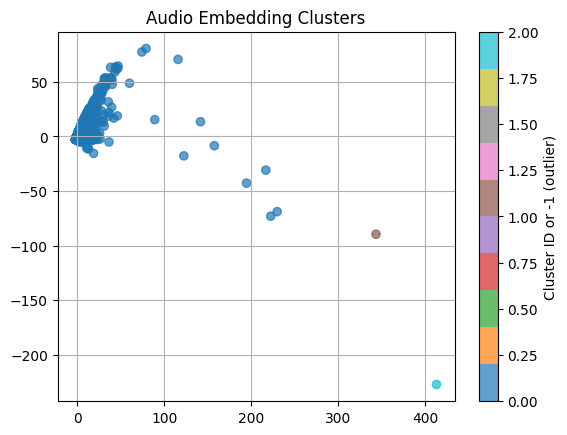

In [80]:
import matplotlib.pyplot as plt

plt.scatter(pca_data.get_samples()[:, 0], pca_data.get_samples()[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.title("Audio Embedding Clusters")
plt.colorbar(label='Cluster ID or -1 (outlier)')
plt.grid(True)
plt.show()

In [31]:
# ─── Jupyter Cell: Similarity Search for “Bad” Audio Clips (preserving original indices) ───
import numpy as np
import pandas as pd
import scipy.io as sio
import librosa
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from collections import Counter

# 1) Load .mat and build DataFrame WITHOUT resetting index,
#    so df.index == original row numbers
phase2  = sio.loadmat('../data/phase2_data_20220215.mat')
samples = pd.DataFrame(phase2['x'].T)
labels  = pd.DataFrame(phase2['y'].T, columns=['y'])
df = pd.concat([samples, labels], axis=1).dropna()

# 2) Build a mapping from original index → positional index in df
pos_map = {orig_idx: pos for pos, orig_idx in enumerate(df.index)}

# 3) Feature‐extraction helper
def extract_features(wav: np.ndarray, sr: int = 48000, n_mfcc: int = 13) -> np.ndarray:
    wav = wav.astype(np.float32)
    if np.max(np.abs(wav)) > 0:
        wav /= np.max(np.abs(wav))
    mfcc     = librosa.feature.mfcc(y=wav, sr=sr, n_mfcc=n_mfcc)
    centroid = librosa.feature.spectral_centroid(y=wav, sr=sr)
    rolloff  = librosa.feature.spectral_rolloff(y=wav, sr=sr)
    zcr      = librosa.feature.zero_crossing_rate(y=wav)
    rms      = librosa.feature.rms(y=wav)
    feats = []
    for arr in (mfcc, centroid, rolloff, zcr, rms):
        feats.append(arr.mean(axis=1))
        feats.append(arr.var(axis=1))
    return np.hstack(feats)  # → 34-D

# 4) Compute features for all clips (in df order)
all_feats = np.vstack([
    extract_features(row[:-1].values)
    for _, row in df.iterrows()
])  # shape (len(df), 34)

# 5) PCA → 10D embeddings
pca   = PCA(n_components=10, random_state=0)
X_emb = pca.fit_transform(all_feats)  # shape (len(df), 10)

# 6) Build cosine‐NN index
nn = NearestNeighbors(n_neighbors=50, metric='cosine', n_jobs=-1)
nn.fit(X_emb)

# 7) Your manually-identified original-row-indices of bad clips
bad_indices = [
    100,303,496,507,609,706,909,1011,1113,1271,1373,1475,1577,1679,1781,1883,2085,2287,
    2389,2489,2789,2891,2895,2995,3096,3497,3767,3997,4099,4201,4499,4699,5199,5301,
    5302,5500,7688,7690,7691,7692,7696,7702,7704,7708,7715,7723,7727,7810,7841,7870,
    7888,7936,7941,7965,7997,8061,8080,8081,8095,8098,8124,8125,8126,8127,8128,8132,
    8156,8157,8158,8159,8160,8161,8215,8261,8302,8310,8322,8395,8425,8477,8478,8479,
    8483,8487,8491,8496,8527,8563,8587,8642,8743,8848,
    0,94,98,102,203,403,505,607,611,708,809,1009,1111,1171,1273,1473,1575,1579,1635,
    1660,1674,1681,1881,1983,1985,2087,2088,2187,2246,2387,2589,2689,2791,2893,3196,
    3455,3495,3696,3798,3999,4199,4701,4748,4749,4798,4999,5201,5209,5244,5245,5255,
    5924,5945,5977,6128,6135,6229,6271,6299,6377,6383,6388,6389,6678,6760,6903,6906,
    6935,6936,7430,7582,7694,7698,7699,7700,7706,7710,7713,7717,7718,7777,7778,7856,
    7872,7939,7943,7960,7984,7999,8046,8048,8059,8063,8064,8068,8078,8083,8084,8085,
    8093,8165,8166,8191,8308,8366,8397,8398,8481,8485,8489,8493,8494,8498,8544,8565,
    8640,8692,8798,8902
]
# Convert to positional indices, skipping any that dropped out
bad_pos = [pos_map[i] for i in bad_indices if i in pos_map]

# 8) Find neighbors of these bad clips
dists, nbrs = nn.kneighbors(X_emb[bad_pos])

# 9) Count how often each neighbor position appears (exclude bad_pos themselves)
flat = nbrs.flatten()
flat = flat[~np.isin(flat, bad_pos)]
counts = Counter(flat)

# 10) Build candidate list keyed by ORIGINAL indices
cand_list = []
for pos, cnt in counts.items():
    orig_idx = df.index[pos]
    # average distance over all occurrences
    avg_dist = dists[nbrs == pos].mean()
    cand_list.append((orig_idx, cnt, avg_dist))

cand_df = pd.DataFrame(cand_list, columns=['audio_index','count','avg_distance'])
# use the original audio_index as the DataFrame index
cand_df.set_index('audio_index', inplace=True)
# sort by frequency (desc) then distance (asc)
cand_df.sort_values(['avg_distance'], ascending=False, inplace=True)

# 11) Display your top candidates
cand_df.head(50)

,count,avg_distance
audio_index,,
1519,12,0.046596
6923,12,0.046283
7577,12,0.045413
7642,11,0.045167
6927,12,0.044623
7763,11,0.044081
1970,11,0.040651
1212,10,0.039013
5891,11,0.038680


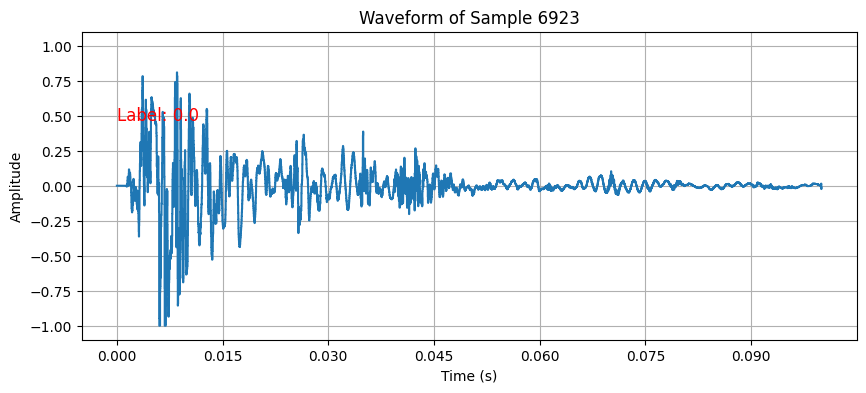

In [38]:
#display waveform using librosa of a certain index in dataframe
import librosa.display
import matplotlib.pyplot as plt
index_to_display = 6923  # Change this to the index you want to display
sample_rate = 48000  # Assuming the sample rate is 48000 Hz
wav = df.iloc[index_to_display, :-1].values.astype(np.float32)
label= df.iloc[index_to_display, -1]  # Get the label for the clip
plt.figure(figsize=(10, 4))
librosa.display.waveshow(wav, sr=sample_rate)
plt.title(f'Waveform of Sample {index_to_display}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
#label in plot
plt.text(0, 0.5, f'Label: {label}', fontsize=12, color='red', ha='left', va='center')
plt.grid()
plt.show()


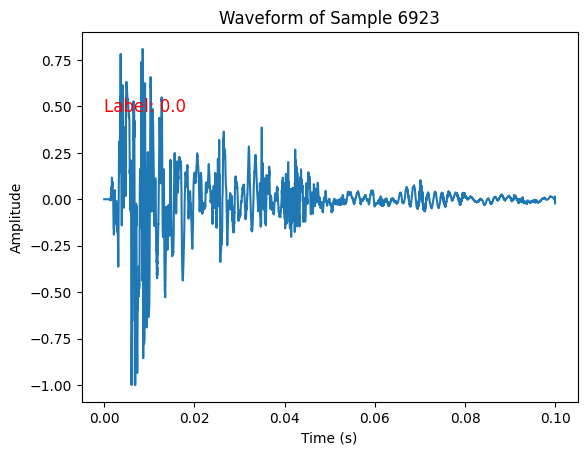

In [39]:
#display audio waveform only using matplotlib
import matplotlib.pyplot as plt
index_to_display = 6923  # Change this to the index you want to display
sample_rate = 48000  # Assuming the sample rate is 48000 Hz
wav = df.iloc[index_to_display, :-1].values
plt.plot(np.arange(len(wav)) / sample_rate, wav)
plt.title(f'Waveform of Sample {index_to_display}')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
#label in plot
label = df.iloc[index_to_display, -1]  # Get the label for the clip
plt.text(0, 0.5, f'Label: {label}', fontsize=12, color='red', ha='left', va='center')
plt.show()

In [33]:
#listen to an audio clip using librosa
import IPython.display as ipd
index_to_listen = 1519  # Change this to the index you want to listen
wav = df.iloc[index_to_listen, :-1].values.astype(np.float32)
ipd.display(ipd.Audio(wav, rate=48000))  # Assuming the sample rate is 48000 Hz
